# Tarea 3 — Pruebas de Hipótesis
## Caso de estudio: Vitalcol EPS — decisiones basadas en evidencia estadística

**Maestría en Informática — Aprendizaje Estadístico**

En este notebook se resuelven los tres ejercicios del caso Vitalcol EPS. Para cada ejercicio se desarrollan las siguientes secciones:

1. Planteamiento del problema
2. Formulación de hipótesis (H₀ y H₁)
3. Selección de la prueba
4. Análisis exploratorio
5. Ejecución de la prueba
6. Conclusión de negocio
7. Limitaciones

Nivel de significancia por defecto: **α = 0.05**


In [34]:
%pip install numpy pandas matplotlib seaborn scipy statsmodels

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
# Imports generales (ejecutar primero)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.stats.api as sms

sns.set_theme(style="whitegrid")


---
# Ejercicio 1 — Costos operativos del programa CPV

**Nivel:** introductorio
**Prueba esperada:** comparación de medias entre dos grupos independientes.

**Contexto:** El Comité Financiero de Vitalcol está preocupado por el impacto del programa CPV en los costos
operativos: la contratación de personal adicional de triage podría estar encareciendo la atención. Se pide
determinar si el costo promedio por consulta prioritaria (en miles de pesos colombianos) difiere entre las
clínicas piloto (con CPV) y las clínicas control (sin CPV).

**Preguntas guía:**

a) ¿Existe evidencia de que el costo promedio por consulta es distinto entre clínicas piloto y control? Plantea la prueba como una comparación de dos colas.

b) Si encuentras una diferencia estadísticamente significativa, ¿es lo suficientemente grande (en pesos) como para preocupar al Comité Financiero? Argumenta tu respuesta más allá del valor p.

c) ¿Qué recomendación le darías al Comité Financiero con base en tu análisis?


### Datos del ejercicio

Ejecutar el siguiente código tal cual (no modificar).

In [36]:
np.random.seed(100)

# Costo por consulta prioritaria, en miles de pesos colombianos (COP)
costo_piloto = np.random.normal(85, 15, 140).clip(min=20)
costo_control = np.random.normal(80, 14, 130).clip(min=20)

df_costos = pd.concat([
    pd.DataFrame({'clinica': 'Piloto', 'costo_miles_cop': costo_piloto}),
    pd.DataFrame({'clinica': 'Control', 'costo_miles_cop': costo_control}),
], ignore_index=True)

df_costos.head()


,clinica,costo_miles_cop
0,Piloto,58.753518
1,Piloto,90.140206
2,Piloto,102.295537
3,Piloto,81.213459
4,Piloto,99.719812


### 1. Planteamiento del problema


> El Comité Financiero de Vitalcol sospecha que el programa CPV, al requerir personal adicional de triage, podría estar incrementando el costo por consulta. El objetivo de este análisis es determinar, con evidencia estadística, si el costo promedio por consulta prioritaria (en miles de COP) difiere entre las clínicas piloto (con CPV) y las clínicas control (sin CPV), para apoyar la decisión de si el programa debe escalarse a nivel nacional.

### 2. Formulación de hipótesis


> - H₀: μ_piloto = μ_control
> - H₁: μ_piloto ≠ μ_control
> - Tipo de prueba : dos colas
> - Justificación: Se pide evaluar si existe alguna diferencia entre las clinicas con y sin CPV, el Comité Financiero se preocuparía tanto si el CPV resulta mas caro como si resultara mas barato.


### 3. Selección de la prueba


> - La variable costo_miles_cop es de tipo numerica continua
> - Se esta comparando dos grupos, clínicas piloto (con CPV) y clínicas control (sin CPV).
> - Las muestras son independientes, son consultas provenientes de conjuntos de clínicas distintos.
> - Por el Teorema del Límite Central se espera que la prueba t sea robusta aunque los datos no sean perfectamente normales.
> - Se utilizara la prueba t de Student para dos muestras independientes, con la variante de Welch (`equal_var=False`), ya que no se puede asumir de antemano que ambos grupos tengan la misma varianza.

### 4. Análisis exploratorio



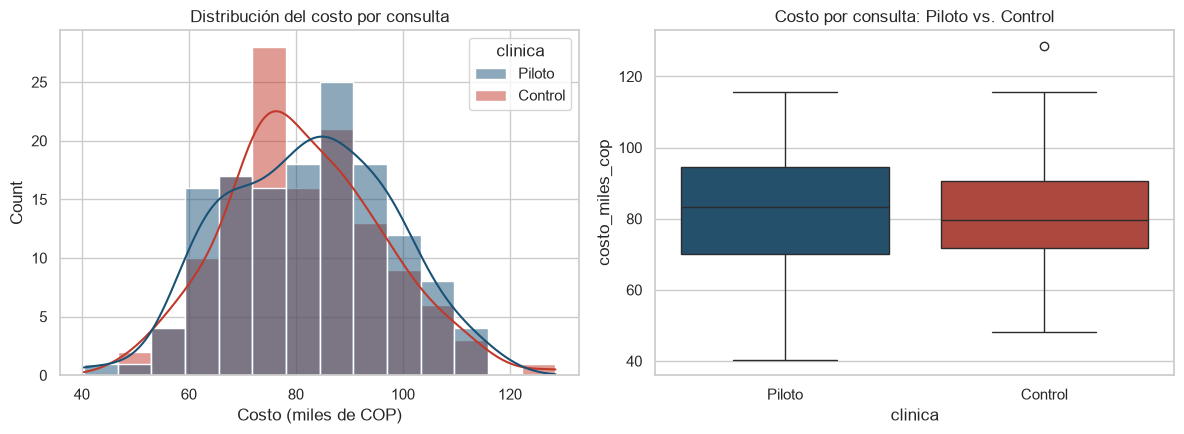

              mean        std  count
clinica                             
Control  81.621352  14.536942    130
Piloto   82.369618  15.137965    140


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Histograma comparado (uno por grupo)
sns.histplot(data=df_costos, x="costo_miles_cop", hue="clinica", kde=True, ax=axes[0], palette=["#1a5276", "#c0392b"])
axes[0].set_title("Distribución del costo por consulta")
axes[0].set_xlabel("Costo (miles de COP)")

# Boxplot comparado
sns.boxplot(data=df_costos, x="clinica", y="costo_miles_cop", hue="clinica", legend=False,
            ax=axes[1], palette=["#1a5276", "#c0392b"])
axes[1].set_title("Costo por consulta: Piloto vs. Control")

plt.tight_layout()
plt.show()

print(df_costos.groupby("clinica")["costo_miles_cop"].agg(["mean", "std", "count"]))

> - Tanto el grupo piloto como el control muestran una distribución aproximadamente simétrica, sin sesgo  extremo evidente, similar a una campana normal. Las varianzas lucen comparables entre ambos grupos, aunque no idénticas, por lo que se mantiene  la decisión de usar la corrección de Welch (equal_var=False). Se observa además un  posible outlier en el grupo control, pero no compromete la forma general de la distribución. Dado que  n=140 y n=130 son muestras razonablemente grandes, el Teorema del Límite Central respalda el uso de la  prueba t incluso ante desviaciones menores de la normalidad perfecta.

> - Al calcular las medias exactas, la diferencia observada es de apenas ~0.75 miles de COP , mucho menor de lo que sugería la inspección visual del histograma. Las desviaciones estándar (15.14 y 14.54)  son muy similares entre los dos grupos. Esto anticipa que, aunque exista una diferencia, es probable que sea  pequeña.

### 5. Ejecución de la prueba



In [38]:

t_stat, p_value = stats.ttest_ind(
    df_costos[df_costos['clinica'] == 'Piloto']['costo_miles_cop'],
    df_costos[df_costos['clinica'] == 'Control']['costo_miles_cop'],
    equal_var=False,     # corrección de Welch
    alternative='two-sided'
)

print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p:       {p_value:.4f}")

if p_value < 0.05:
    print("\nRechazamos H0: hay evidencia de que el costo promedio difiere entre clínicas piloto y control.")
else:
    print("\nNo rechazamos H0: no hay evidencia suficiente de una diferencia en el costo promedio.")

Estadístico t: 0.4143
Valor p:       0.6790

No rechazamos H0: no hay evidencia suficiente de una diferencia en el costo promedio.


### 6. Conclusión de negocio

> - El análisis no encontró evidencia de que el programa CPV haya incrementado el costo promedio por consulta prioritaria: la diferencia observada entre clínicas piloto y control (82.37 vs. 81.62 miles de COP) es estadísticamente indistinguible de cero (valor p = 0.679) y, en términos prácticos, representa menos del 1% del costo promedio, una magnitud demasiado pequeña como para preocupar al Comité Financiero incluso si hubiera resultado significativa. 
> - En consecuencia, la preocupación inicial sobre un coste mas alto causado por el personal adicional de triage no se sostiene con los datos, y el factor costo no debería ser un obstáculo para evaluar la expansión del programa a nivel nacional.


### 7. Limitaciones

> - Los datos no dicen si esta comparación se hizo en un momento específico del piloto, el costo podría cambiar con el tiempo.
> - No sabemos cómo se asignaron las clinicas a "piloto" vs "control", si no fue aleatorio podria haber otras diferencias que afecten el costo y que no estamos controlando en este caso.


### Preguntas guía — Ejercicio 1

a) ¿Existe evidencia de que el costo promedio por consulta es distinto entre clínicas piloto y control? Plantea la prueba como una comparación de dos colas.

b) Si encuentras una diferencia estadísticamente significativa, ¿es lo suficientemente grande (en pesos) como para preocupar al Comité Financiero? Argumenta tu respuesta más allá del valor p.

c) ¿Qué recomendación le darías al Comité Financiero con base en tu análisis?


> a) No, se planteó una prueba t de dos muestras independientes, de dos colas (H₀: μ_piloto = μ_control vs. H₁: μ_piloto ≠ μ_control), obteniendo un valor p = 0.679, muy por encima de α = 0.05. Por lo tanto, no hay evidencia estadística de que el costo promedio difiera entre clínicas piloto y control.
>
> b) No, la diferencia ni siquiera fue estadísticamente significativa. No obstante, la diferencia observada (82.37 vs. 81.62 miles de COP, ≈750 pesos) representa menos del 1% del costo promedio por consulta, por lo que tampoco tendría relevancia práctica aunque hubiera resultado significativa con una muestra más grande.
>
> c) Se recomienda al Comité Financiero no considerar el costo por consulta como una barrera para escalar el programa CPV, ya que no se encontró evidencia de que este incremente los costos operativos frente a las clínicas control.



---
# Ejercicio 2 — Comparación de modalidades de triage digital

**Nivel:** intermedio
**Pruebas esperadas:** comparación de medias entre 3+ grupos, y prueba de independencia entre variables categóricas.

**Contexto:** Vitalcol evalúa tres modalidades de triage digital para su siguiente fase de expansión:

- **Modalidad A:** únicamente síntomas auto-reportados por el paciente.
- **Modalidad B:** añade signos vitales capturados por un dispositivo wearable.
- **Modalidad C:** suma además un modelo de priorización basado en inteligencia artificial.

El equipo médico necesita responder dos preguntas independientes sobre estas tres modalidades.


### Datos del ejercicio

Ejecutar el siguiente código tal cual (no modificar).

In [6]:
np.random.seed(101)

# --- Parte A: tiempo (min) hasta la primera atencion medica ---
modalidad_A = np.random.normal(24, 5, 90).clip(min=5)
modalidad_B = np.random.normal(19, 5, 90).clip(min=5)
modalidad_C = np.random.normal(15, 4, 90).clip(min=5)

df_tiempos = pd.concat([
    pd.DataFrame({'modalidad': 'A', 'tiempo_atencion_min': modalidad_A}),
    pd.DataFrame({'modalidad': 'B', 'tiempo_atencion_min': modalidad_B}),
    pd.DataFrame({'modalidad': 'C', 'tiempo_atencion_min': modalidad_C}),
], ignore_index=True)

# --- Parte B: ocurrencia de complicaciones evitables ---
modalidad = np.repeat(['A', 'B', 'C'], 90)
prob_complicacion = np.select(
    [modalidad == 'A', modalidad == 'B', modalidad == 'C'],
    [0.15, 0.09, 0.04]
)
complicacion = np.random.binomial(1, prob_complicacion)

df_modalidad = pd.DataFrame({
    'modalidad': modalidad,
    'complicacion_evitable': np.where(complicacion == 1, 'Sí', 'No')
})

df_tiempos.head()


,modalidad,tiempo_atencion_min
0,A,37.534249
1,A,27.140664
2,A,28.539847
3,A,26.519129
4,A,27.255590


## Parte A — Tiempo hasta la primera atención

Usa el DataFrame `df_tiempos`. ¿Existe evidencia de que el tiempo promedio hasta la primera atención difiere entre las tres modalidades?


### 1. Planteamiento del problema

> Vitalcol quiere saber si el tiempo promedio hasta la primera atención médica es igual entre las tres modalidades de triage digital (A: solo síntomas auto-reportados, B: se le suman los signos vitales, C: + IA de priorización), o si al menos una modalidad se demora diferente que las otras. Esto es clave porque de acá depende si vale la pena invertir en la tecnología más completa para la expansión.


### 2. Formulación de hipótesis


> - H₀: μ_A = μ_B = μ_C (el tiempo promedio de atención es igual en las tres modalidades)
> - H₁: al menos una μ_i es diferente de las demás
> - Tipo de prueba: no aplica lo de "una o dos colas" acá porque el análisis de varianza es inherentemente una prueba global (F), no se plantea por dirección. Lo que sí definimos es que es una prueba de un factor (la modalidad) con 3 niveles.
> - Justificación: como son 3 grupos y no 2, no podemos usar t-test directo, necesitamos una prueba que compare las 3 medias simultáneamente.


### 3. Selección de la prueba

> - La variable tiempo_atencion_min es numérica continua.
> - Se comparan 3 grupos independientes (cada paciente pasó por una sola modalidad, no por las tres).
> - Toca revisar normalidad y homogeneidad de varianzas antes de decidir entre ANOVA (paramétrica) o Kruskal-Wallis (no paramétrica).


### 4. Análisis exploratorio

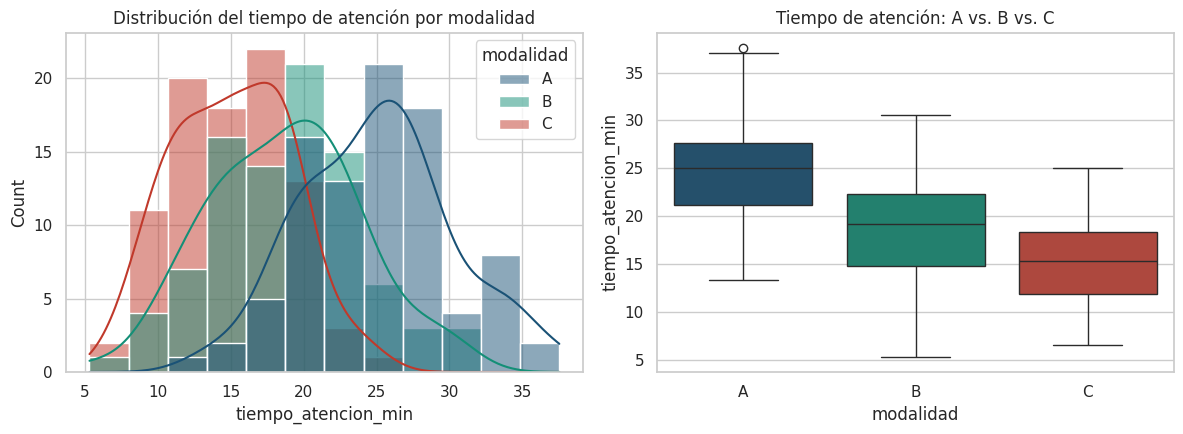

                mean       std  count
modalidad                            
A          25.042565  5.147530     90
B          18.741810  5.149579     90
C          15.111216  4.034495     90
Shapiro-Wilk modalidad A: estadístico=0.9871, p=0.5185
Shapiro-Wilk modalidad B: estadístico=0.9921, p=0.8722
Shapiro-Wilk modalidad C: estadístico=0.9855, p=0.4177

Levene: estadístico=2.0918, p=0.1255


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(data=df_tiempos, x="tiempo_atencion_min", hue="modalidad", kde=True,
             ax=axes[0], palette=["#1a5276", "#148f77", "#c0392b"])
axes[0].set_title("Distribución del tiempo de atención por modalidad")

sns.boxplot(data=df_tiempos, x="modalidad", y="tiempo_atencion_min", hue="modalidad",
            legend=False, ax=axes[1], palette=["#1a5276", "#148f77", "#c0392b"])
axes[1].set_title("Tiempo de atención: A vs. B vs. C")

plt.tight_layout()
plt.show()

print(df_tiempos.groupby("modalidad")["tiempo_atencion_min"].agg(["mean", "std", "count"]))

# Shapiro-Wilk por grupo (normalidad)
for m in ['A', 'B', 'C']:
    datos_m = df_tiempos[df_tiempos['modalidad'] == m]['tiempo_atencion_min']
    sh_stat, sh_p = stats.shapiro(datos_m)
    print(f"Shapiro-Wilk modalidad {m}: estadístico={sh_stat:.4f}, p={sh_p:.4f}")

# Levene (homogeneidad de varianzas)
lev_stat, lev_p = stats.levene(
    df_tiempos[df_tiempos.modalidad=='A']['tiempo_atencion_min'],
    df_tiempos[df_tiempos.modalidad=='B']['tiempo_atencion_min'],
    df_tiempos[df_tiempos.modalidad=='C']['tiempo_atencion_min']
)
print(f"\nLevene: estadístico={lev_stat:.4f}, p={lev_p:.4f}")

### 5. Ejecución de la prueba

In [17]:
f_stat, p_anova = stats.f_oneway(modalidad_A, modalidad_B, modalidad_C)
print(f"Estadístico F: {f_stat:.4f}")
print(f"Valor p: {p_anova:.6g}")

if p_anova < 0.05:
    print("\nRechazamos H0: al menos una modalidad tiene un tiempo promedio distinto.")
else:
    print("\nNo rechazamos H0: no hay evidencia de diferencias entre modalidades.")

Estadístico F: 98.3955
Valor p: 9.6654e-33

Rechazamos H0: al menos una modalidad tiene un tiempo promedio distinto.


### 6. Conclusión de negocio

> Hay evidencia estadística muy fuerte de que el tiempo promedio hasta la primera atención sí difiere entre las tres modalidades de triage. En los datos, la Modalidad A (solo síntomas) tarda en promedio ~25 minutos, la B (+ signos vitales) ~18.7 minutos, y la C (+ IA) ~15.1 minutos. Es decir, entre más información use el sistema para priorizar al paciente, más rápido se le atiende. La diferencia no es solo estadísticamente significativa, sino que en la práctica representa casi 10 minutos menos de espera comparando A contra C, algo que sí importa clínicamente en un servicio de urgencias.


### 7. Limitaciones

> ANOVA nos dice que al menos una modalidad difiere de las otras, pero no nos dice específicamente cuáles pares son distintos entre sí (ej. si A≠B, o si solo C es la que se sale del grupo). Para eso se necesitaría una prueba post-hoc para identificar cuáles modalidades específicas difieren entre sí.

## Parte B — Complicaciones evitables

Usa el DataFrame `df_modalidad`. ¿El tipo de modalidad está asociado con la ocurrencia de complicaciones evitables?


### 1. Planteamiento del problema

> Ahora Vitalcol quiere saber si el tipo de modalidad de triage está asociado con que ocurra o no una complicación evitable. Esto es importante porque no solo importa la velocidad de atención (Parte A), sino también la calidad/seguridad clínica del proceso.


### 2. Formulación de hipótesis


> - H₀: la modalidad de triage y la ocurrencia de complicaciones evitables son independientes
> - H₁: la modalidad de triage y la ocurrencia de complicaciones evitables están asociadas
> - Tipo de prueba: Chi-cuadrado de independencia (no tiene sentido hablar de "colas" acá, es una prueba no direccional por naturaleza)
> - Justificación: ambas variables son categóricas (modalidad: A/B/C, complicación: Sí/No), así que no podemos usar una prueba de medias.


### 3. Selección de la prueba

> - Ambas variables son categóricas nominales.
> - Se construye una tabla de contingencia 3x2 (modalidad x complicación).
> - La prueba adecuada para evaluar asociación entre dos categóricas es Chi-cuadrado de independencia.


### 4. Análisis exploratorio

Tabla de contingencia (conteos):
complicacion_evitable  No  Sí
modalidad                    
A                      71  19
B                      81   9
C                      86   4

Proporción de complicaciones por modalidad:
complicacion_evitable        No        Sí
modalidad                                
A                      0.788889  0.211111
B                      0.900000  0.100000
C                      0.955556  0.044444


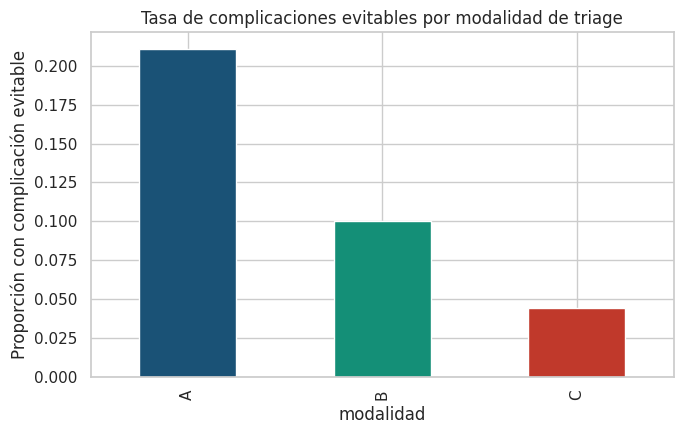

In [18]:
tabla_contingencia = pd.crosstab(df_modalidad['modalidad'], df_modalidad['complicacion_evitable'])
print("Tabla de contingencia (conteos):")
print(tabla_contingencia)

tabla_proporciones = pd.crosstab(df_modalidad['modalidad'], df_modalidad['complicacion_evitable'], normalize='index')
print("\nProporción de complicaciones por modalidad:")
print(tabla_proporciones)

fig, ax = plt.subplots(figsize=(7, 4.5))
tabla_proporciones['Sí'].plot(kind='bar', ax=ax, color=["#1a5276", "#148f77", "#c0392b"])
ax.set_ylabel("Proporción con complicación evitable")
ax.set_title("Tasa de complicaciones evitables por modalidad de triage")
plt.tight_layout()
plt.show()

### 5. Ejecución de la prueba

In [19]:
chi2_stat, p_chi2, dof, esperadas = stats.chi2_contingency(tabla_contingencia)
print(f"Estadístico Chi2: {chi2_stat:.4f}")
print(f"Grados de libertad: {dof}")
print(f"Valor p: {p_chi2:.6g}")

if p_chi2 < 0.05:
    print("\nRechazamos H0: hay evidencia de asociación entre modalidad y complicaciones evitables.")
else:
    print("\nNo rechazamos H0: no hay evidencia de asociación.")

Estadístico Chi2: 12.4081
Grados de libertad: 2
Valor p: 0.00202124

Rechazamos H0: hay evidencia de asociación entre modalidad y complicaciones evitables.


### 6. Conclusión de negocio

> Sí hay evidencia estadística de que el tipo de modalidad de triage está asociado con la probabilidad de que ocurra una complicación evitable. Las clínicas que usan la Modalidad A (solo síntomas reportados) presentan una tasa de complicaciones evitables notablemente más alta ( ~ 21% ) que las que usan la Modalidad C con IA ( ~ 4% ). Esto sugiere que agregar información objetiva (signos vitales y priorización por IA) no solo agiliza la atención, sino que también reduce el riesgo clínico.


### 7. Limitaciones

> Chi-cuadrado nos dice que hay asociación, pero no prueba causalidad: podría haber variables confusoras, por ejemplo si las clínicas que ya usaban Modalidad C eran las que tenían mejor personal médico o mejor infraestructura de por sí, independientemente de la tecnología de triage.


### Preguntas guía — Ejercicio 2

a) Si la prueba de la Parte A resulta significativa, ¿qué información adicional necesitarías para saber cuál(es) modalidad(es) específica(s) difiere(n) de las demás?

> Como ANOVA sí salió significativa, para saber cuáles modalidades específicamente difieren entre sí necesitaríamos una prueba post-hoc, que hace comparaciones por pares controlando el error tipo I acumulado.

b) ¿Qué implicación tiene, para la decisión de inversión de Vitalcol, encontrar evidencia en ambas partes (A y B) a favor de la Modalidad C frente a las otras dos?

> Que en ambas partes (tiempo y complicaciones) la Modalidad C salga ganando es una señal fuerte a favor de invertir en ella: no es solo más rápida, sino también más segura. Eso le da mucho más peso a la decisión de escalarla, porque no se está sacrificando calidad por velocidad (que sería la preocupación obvia si solo tuvieras la Parte A).

c) ¿Qué otra variable te gustaría medir para descartar explicaciones alternativas antes de recomendar la Modalidad C como la única opción a escalar?

> Antes de recomendar la Modalidad C como única opción, valdría la pena medir cosas como, la experiencia/antigüedad del personal médico en cada clínica (para descartar que el efecto sea del personal y no de la tecnología), la gravedad promedio de los pacientes atendidos en cada modalidad (si las clínicas C reciben casos menos complejos, eso sesga la comparación), y el costo de implementación de C frente a A y B, para que la recomendación no sea solo clínica sino también viable financieramente.



---
# Ejercicio 3 — Evaluación del programa de capacitación en triage

**Nivel:** avanzado
**Diseño abierto:** tú decides el tipo de muestras, el supuesto de normalidad a verificar, y la prueba a aplicar.

**Contexto:** El área de Recursos Humanos de Vitalcol implementó un nuevo programa de capacitación en triage
digital para el personal de enfermería de las clínicas piloto. Antes y después de tomar la capacitación, cada
enfermero(a) presentó una evaluación de competencias (escala de 0 a 100), aplicada por la misma entidad
certificadora. Recursos Humanos quiere saber si el programa de capacitación mejoró el desempeño de su
personal, antes de decidir si lo hace obligatorio para todas las clínicas del país.


### Datos del ejercicio

Ejecutar el siguiente código tal cual (no modificar).

In [44]:
np.random.seed(102)

n_enfermeros = 28
puntaje_antes = np.clip(np.random.normal(68, 10, n_enfermeros), 0, 100)
mejora_capacitacion = np.random.normal(9, 6, n_enfermeros)
puntaje_despues = np.clip(puntaje_antes + mejora_capacitacion, 0, 100)

df_capacitacion = pd.DataFrame({
    'enfermero_id': range(1, n_enfermeros + 1),
    'puntaje_antes': puntaje_antes,
    'puntaje_despues': puntaje_despues
})

df_capacitacion.head()


,enfermero_id,puntaje_antes,puntaje_despues
0,1,84.680683,98.053185
1,2,77.258618,86.433459
2,3,78.579968,85.833653
3,4,58.796610,69.682368
4,5,80.997485,95.980623


### 1. Planteamiento del problema

> El área de Recursos Humanos de Vitalcol desea saber si el desempeño del personal de enfermería mejoró tras la capacitación en triage digital, medido a través de una evaluación de competencias (escala 0-100) aplicada antes y después del programa a cada enfermero. Esto con el fin de decidir si el programa de capacitación debe hacerse obligatorio para todas las clínicas del país.



### 2. Formulación de hipótesis

>Sea D = puntaje_despues − puntaje_antes, la diferencia en el puntaje de competencias de cada enfermero(a) tras la capacitación.

> - H₀: La media (o mediana) de las diferencias es igual a 0
> - H₁: La media (o mediana) de las diferencias es mayor a 0
> - Tipo de prueba: Una cola (cola derecha)
> - Justificación: La pregunta de negocio responde a si el puntaje especificamente mejoró. A Recursos Humanos le interesa solo por que haya una evidencia de mejora, por eso se plantea como una prueba de una cola.


### 3. Selección de la prueba

**a) Determina si las dos mediciones (antes/después) deben tratarse como muestras independientes o pareadas, y justifica tu respuesta.**

> - La variable (puntaje de competencias) es numérica continua.
> - Las muestras son **pareadas**: cada enfermero(a) tiene dos mediciones (`puntaje_antes` y `puntaje_despues`) tomadas sobre la misma unidad de observación, en dos momentos distintos, con el mismo instrumento de evaluación .
> - El supuesto de normalidad (sobre la variable diferencia, no sobre antes/después por separado) se evaluará visualmente en el punto 4.
> - Prueba candidata: por tratarse de datos pareados, la elección está entre la prueba t pareada (`scipy.stats.ttest_rel`, paramétrica) y la prueba de Wilcoxon (`scipy.stats.wilcoxon`, no paramétrica). 
>  La decisión final se justificará en el punto 5, con base en el análisis exploratorio.




### 4. Análisis exploratorio  

**b) Evalúa visualmente si la variable de interés (la diferencia entre el puntaje después y antes) luce razonablemente simétrica/normal, y documenta qué observas.**


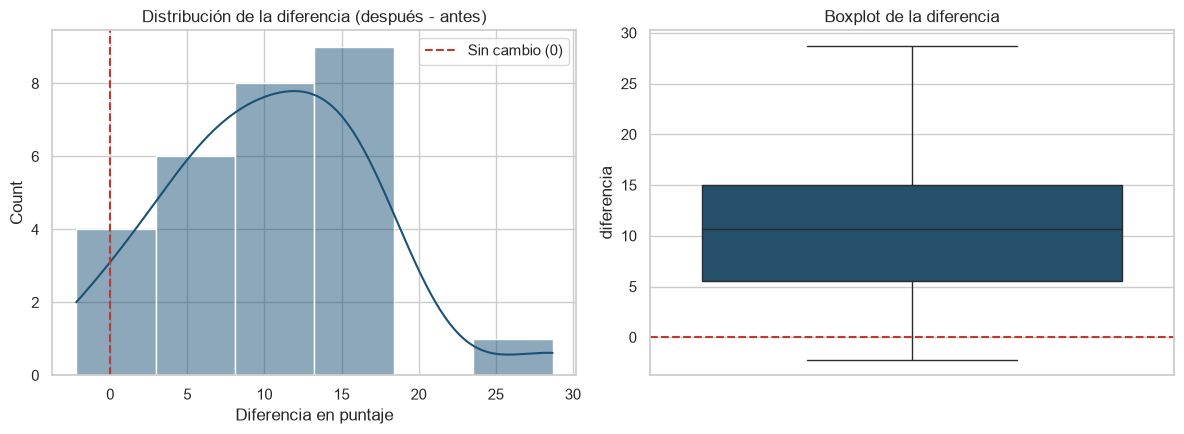

mean      10.430885
median    10.645972
std        6.653490
count     28.000000
Name: diferencia, dtype: float64


In [48]:
df_capacitacion["diferencia"] = df_capacitacion["puntaje_despues"] - df_capacitacion["puntaje_antes"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Histograma de la diferencia
sns.histplot(df_capacitacion["diferencia"], kde=True, ax=axes[0], color="#1a5276")
axes[0].axvline(0, color="#c0392b", linestyle="--", label="Sin cambio (0)")
axes[0].set_title("Distribución de la diferencia (después - antes)")
axes[0].set_xlabel("Diferencia en puntaje")
axes[0].legend()

# Boxplot de la diferencia
sns.boxplot(y=df_capacitacion["diferencia"], ax=axes[1], color="#1a5276")
axes[1].axhline(0, color="#c0392b", linestyle="--")
axes[1].set_title("Boxplot de la diferencia")

plt.tight_layout()
plt.show()

print(df_capacitacion["diferencia"].agg(["mean", "median", "std", "count"]))


> b) La distribución de la diferencia (después - antes) muestra una forma aproximadamente simétrica tipo campana, con la gran mayoría de los valores por encima de cero, lo que podria significar una mejora general en el desempeño tras la capacitación. Se observa una leve cola hacia la derecha, pero no se identifican outliers en el boxplot. El indicador más informativo es que la media (10.43) y la mediana (10.65) son casi idénticas, lo cual es evidencia de que no hay un sesgo fuerte en los datos. Dado que n=28 es una muestra pequeña, esta cercanía entre media y mediana pesa más que el Teorema del Límite Central para sustentar el supuesto de normalidad.

### 5. Ejecución de la prueba

**c) Con base en el punto anterior, elige y justifica si aplicarías una prueba paramétrica o no paramétrica. Ejecuta la prueba elegida.**

> Se elige la prueba t pareada (`ttest_rel`), una prueba paramétrica, porque el análisis exploratorio del punto b) mostró evidencia razonable de que el supuesto de normalidad se cumple: la media (10.43) y la mediana (10.65) de las diferencias son casi idénticas, la forma de la distribución es aproximadamente simétrica tipo campana, y no se identificaron outliers. Al cumplirse el supuesto, se prefiere la prueba paramétrica porque tiene mayor validez estadística que su alternativa no paramétrica  para detectar un efecto real, dado el mismo tamaño de muestra.





In [49]:
t_stat, p_value = stats.ttest_rel(
    df_capacitacion["puntaje_despues"],
    df_capacitacion["puntaje_antes"],
    alternative="greater"   # H1: el puntaje después es mayor que antes (una cola)
)

print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p:       {p_value:.6f}")

if p_value < 0.05:
    print("\nRechazamos H0: hay evidencia de que el desempeño mejoró tras la capacitación.")
else:
    print("\nNo rechazamos H0: no hay evidencia suficiente de mejora en el desempeño.")

Estadístico t: 8.2957
Valor p:       0.000000

Rechazamos H0: hay evidencia de que el desempeño mejoró tras la capacitación.


**d) Ejecuta también la prueba alternativa (la que no elegiste) y compara ambos resultados: ¿cambia la conclusión de negocio según la prueba usada?**

In [50]:

w_stat, p_value_w = stats.wilcoxon(
    df_capacitacion["puntaje_despues"],
    df_capacitacion["puntaje_antes"],
    alternative="greater"   # misma H1: el puntaje después es mayor que antes
)

print(f"Estadístico W: {w_stat:.4f}")
print(f"Valor p:       {p_value_w:.6f}")

if p_value_w < 0.05:
    print("\nRechazamos H0: hay evidencia de que el desempeño mejoró tras la capacitación.")
else:
    print("\nNo rechazamos H0: no hay evidencia suficiente de mejora en el desempeño.")

Estadístico W: 402.0000
Valor p:       0.000000

Rechazamos H0: hay evidencia de que el desempeño mejoró tras la capacitación.


> > d) Al ejecutar también la prueba de Wilcoxon como alternativa no paramétrica, se obtiene un valor p prácticamente igual a 0 (estadístico W = 402.0), la misma conclusión que con la prueba t pareada (estadístico t = 8.30, valor p ≈ 0). En este caso, la conclusión de negocio no cambia según la prueba usada: ambos métodos coinciden en rechazar H₀. Esto es consistente con lo observado en el análisis exploratorio (punto 4), donde la distribución de las diferencias no mostraba un sesgo fuerte cuando el supuesto de normalidad se cumple razonablemente, es esperable que la prueba paramétrica y la no paramétrica lleguen a la misma conclusión.

### 6. Conclusión de negocio

**e) Redacta la recomendación final para Recursos Humanos: ¿debería el programa de capacitación hacerse obligatorio a nivel nacional?**

> Sí, se recomienda hacer obligatorio el programa de capacitación en triage digital para todas las clínicas del país. El análisis muestra una mejora clara y consistente en el desempeño de las enfermeras tras recibir la capacitación: en promedio, los puntajes de competencia subieron cerca de 10.4 puntos (de un total de 100), y esta mejora es estadísticamente muy sólida (valor p prácticamente 0 tanto con la prueba paramétrica como con la no paramétrica).


### 7. Limitaciones

> - El diseño de este análisis no incluyó un punto de comparación (enfermeros que no recibieran la capacitación), por lo que no es posible descartar por completo que parte de la mejora observada se deba a otros factores distintos al programa como el efecto de repetir la misma evaluación una segunda vez, o la experiencia acumulada en el tiempo transcurrido entre ambas mediciones. 
> - Adicionalmente, el puntaje de competencias es una evaluación teórica aplicada por una entidad certificadora, y no mide directamente si esta mejora se traduce en un mejor desempeño de triage con pacientes reales, sería recomendable complementar el análisis con indicadores operativos una vez el programa esté en funcionamiento.